# Introduction


This demo is intended to develop functionalities in Stylise that involves machine learning, surrogate-based optimisation for the Stylise application.
The functionalities developped are the ones performed by Alternova Web for aerodynamic studies, which are :
- Data generation (Design of Experiments)
- Data analysis (Surrogate modeling)
- Data-driven decision (Optimisation)

## Design of Experiments
While this is not the main focus of this demonstration, Alternova performs Design of Experiments prior to the data analysis stage. This can also be performed with scipy to generate Latin-Hypercube sampling and similar. In an "Alternova-less" world, ANSA or similar tools also have DoE functionalities.

## Surrogate modeling
Based on a data table, create a model that can be used to estimate the results for a given response or set of responses
In Alternova, the standard models are : 
- least square regression with term selection, terms are linear, interactions, squares... 
- polymars, ie domain-wise linear regression, with coefficient change based on doman decomposition
Finally, Alternova provides an expert mixture combining the models to use the strongest automatically, with regard to validation results

In scikit-learn, we can replace the least square regression with a more modern Elastic-Net regression.
We can also test SVR (Support-Vector Regression) in "replacement" of polymars (there is no direct equivalent in sklearn).
For the expert mixture, a StackingRegressor should perform better then an averaging VotingRegressor.
The demo shows that a single Elastic-Net on Polynomial Features is sufficient as a first approach.

In all cases, proper cross-validation should be performed. Note that ElasticNet provides an ElasticNetCV variant that performs cross-validation during training. The use of Pipeline is higly recommended, as well as standardization for data preprocessing. 

## Optimisation
Alternova provides tools to optimize a performance by setting minimisation targets and performances constraints. For the sake of demonstration, we will only perform the CdA optimisation without any constraint. scipy provides multiple algorithms for global optimisation, we demonstrate it here with shgo and an evolution algorithm.



In [1]:
# Import the libraries
import pandas as pd
import numpy as np

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import ElasticNetCV, RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import PredictionErrorDisplay

from scipy.optimize import shgo, differential_evolution, dual_annealing

# set_config(transform_output="pandas")

# Surrogate modeling

## Data reading

All data will be read from a csv file from a previous Alternova study and stored in a pandas DataFrame. It should be adapted to meet the source and format of data of Stylise (ie SQL database, json format...)
The demo data doesn't have any empty value, it should also be taken into account during training.

In [2]:
CSV_FILE = "demo_data.csv"
demo_df = pd.read_csv(CSV_FILE, sep=";", decimal=",")
demo_df.describe()

,COUNTER,Front_Bumper_Curvature,Hood_Movement_X,Hood_Movement_Z,Rear_Bumper_Wheel_Covering,Rear_Shoulder_1,Rear_Shoulder_2,Side_Wall_Wheel_Covering_Y,Spoiler_Z,Veh_Apillar,CmpA,CmyA,Vortex_CdA,CdA,CsA,CIA,CIA_Front,CIA_rear,CmrA
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,125.673077,0.465895,-6.133017,-15.059081,12.325203,-2.147603,-0.015830,6.481975,9.385692,0.509582,-0.128111,-0.002583,0.096913,0.722996,0.022909,0.133156,0.017874,0.115282,0.017190
std,15.499173,0.351570,12.940227,11.302502,28.806283,15.955775,14.825865,18.073253,23.988677,0.378822,0.069792,0.007475,0.008546,0.015346,0.011381,0.050507,0.030549,0.041701,0.008198
min,100.000000,0.000000,-25.000000,-30.000000,-30.000000,-30.000000,-20.000000,-20.000000,-30.000000,0.000000,-0.245103,-0.021857,0.080160,0.698373,0.005740,0.045728,-0.022428,-0.026894,-0.000706
25%,112.750000,0.143279,-20.036703,-26.660460,-16.427560,-15.410200,-15.404173,-9.640260,-12.776435,0.120519,-0.176740,-0.007550,0.090908,0.713453,0.016016,0.100896,-0.008605,0.091045,0.011021
50%,125.500000,0.472969,-3.714336,-15.195025,13.827080,1.971160,0.476651,3.711444,11.534685,0.476263,-0.139065,-0.002552,0.096690,0.721845,0.021163,0.130223,0.010891,0.113024,0.015788
75%,138.250000,0.793065,6.769829,-3.999498,40.077687,11.757430,15.979933,25.736090,31.733065,0.897259,-0.099048,0.003040,0.102127,0.734026,0.027193,0.175494,0.040821,0.140464,0.022349
max,160.000000,1.000000,10.000000,0.000000,50.000000,20.000000,20.000000,30.000000,40.000000,1.000000,0.132707,0.017157,0.120180,0.755256,0.053296,0.216869,0.086265,0.192645,0.036739


We prepare some informations for the next steps : the split between descriptors, parameters and responses.

We also know that the first 48 experiments are part of the design of experiments, while the last 4 are optimisation iterations. We will keep these 4 as external validation points. We can change the number of points out of training with the corresponding variable

In [3]:
X_names = ["Front_Bumper_Curvature","Hood_Movement_X","Hood_Movement_Z","Rear_Bumper_Wheel_Covering","Rear_Shoulder_1","Rear_Shoulder_2","Side_Wall_Wheel_Covering_Y","Spoiler_Z","Veh_Apillar"]
Y_names = ["CdA","CsA","CIA","CIA_Front","CIA_rear","CmrA","CmpA","CmyA","Vortex_CdA",]

X = demo_df[X_names]
Y = demo_df[Y_names]

OutOfTrainPoints = 4

X_training_phase = X.iloc[:-OutOfTrainPoints]
Y_training_phase = Y.iloc[:-OutOfTrainPoints]

X_validation_phase = X.iloc[-OutOfTrainPoints:]
Y_validation_phase = Y.iloc[-OutOfTrainPoints:]

# X_train, X_test, Y_train, Y_test = train_test_split(X_training_phase, Y_training_phase, test_size=0.1)

## Pipeline creation

The pipeline that we build consists of :
- Standard Scaler
- Stacking Regressor combining ElasticNet models over various terms sets

The MultiOutputRegressor is used to compute all responses through the same pipeline, as the SVR is not a native multi-output regressor. 

Note that scikit-learn provide the MultiTaskElasticNet. This model forces the models to share the selected features between outputs, and might therefore be inefficient in our case.

Regarding robustness of models, the pipeline incorporate cross-validation by default with :
- ElasticNetCV, a derivative of ElasticNet, implements automaticaly 5 folds cross-validation to fit the coefficients
- StackingRegressor also implements 5 folds cross-validation to determine the expert mixture coefficients

In [4]:
scaler = StandardScaler()
expert_mixture = StackingRegressor(estimators=[
    ("elasticnetlin", ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], )),
    ("elasticnetpoly", Pipeline([("poly", PolynomialFeatures()), ("e_net_p", ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1] ))]))
], final_estimator=LinearRegression())
pipeline = Pipeline([
    ("scaler", scaler),
    ("expert_mixture", MultiOutputRegressor(expert_mixture))
])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('expert_mixture',
                 MultiOutputRegressor(estimator=StackingRegressor(estimators=[('elasticnetlin',
                                                                               ElasticNetCV(l1_ratio=[0.1,
                                                                                                      0.5,
                                                                                                      0.7,
                                                                                                      0.9,
                                                                                                      0.95,
                                                                                                      0.99,
                                                                                                      1])),
                                                                              ('elasticnetpoly',
                                                                               Pipeline(steps=[('poly',
                                                                                                PolynomialFeatures()),
                                                                                               ('e_net_p',
                                                                                                ElasticNetCV(l1_ratio=[0.1,
                                                                                                                       0.5,
                                                                                                                       0.7,
                                                                                                                       0.9,
                                                                                                                       0.95,
                                                                                                                       0.99,
                                                                                                                       1]))]))],
                                                                  final_estimator=LinearRegression())))])

In [5]:
pipeline.fit(X_training_phase, Y_training_phase)
pipeline.score(X_training_phase, Y_training_phase)

0.6449729252344596

In [6]:
final_estimator = pipeline[:-1]

## Visual and scalar checks

scikit provides a simple function to plot True v Estimated after a model fitting. 
We will only plot CdA for demonstration purpose, but the data for all output columns will be shown after.
The score we look into are :
- R² score, for general assesment. The closer to 1 the better.
- Mean absolute error, to give a general idea of the error we can expect from a prediction. Expressed in the same units than the prediction (ie m² for CdA)
- Mean absolute percentage error, to transpose the previous error in a percentage of the truth value
- Max error, to propose an upper bound of the error we do

In [7]:
Y_pred_train = pipeline.predict(X_training_phase)
# Y_pred_test = pipeline.predict(X_test)
Y_pred_validation = pipeline.predict(X_validation_phase)

# We focus on the CdA prediction
CdA_train = Y_training_phase["CdA"]
CdA_pred_train = Y_pred_train[:, Y.columns.get_loc("CdA")]
# CdA_test = Y_test["CdA"]
# CdA_pred_test = Y_pred_test[:, Y.columns.get_loc("CdA")]
CdA_validation = Y_validation_phase["CdA"]
CdA_pred_validation = Y_pred_validation[:, Y.columns.get_loc("CdA")]

# We also set the "acceptable error" for visual cues
ERR = 0.005

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def add_translated_lines(display, translation_value):
    # Get the limits of the plot
    x_min, x_max = display.ax_.get_xlim()
    # Generate x values for the lines
    x_values = np.linspace(x_min, x_max, 2)
    # Calculate y values for the parallel lines
    y_values1 = x_values + translation_value
    y_values2 = x_values - translation_value
    # Plot the parallel lines
    display.ax_.plot(x_values, y_values1, 'k.:', label=f'+/-{translation_value}m²')
    display.ax_.plot(x_values, y_values2, 'k.:')

    return x_min, x_max, y_values1[0], y_values2[1]


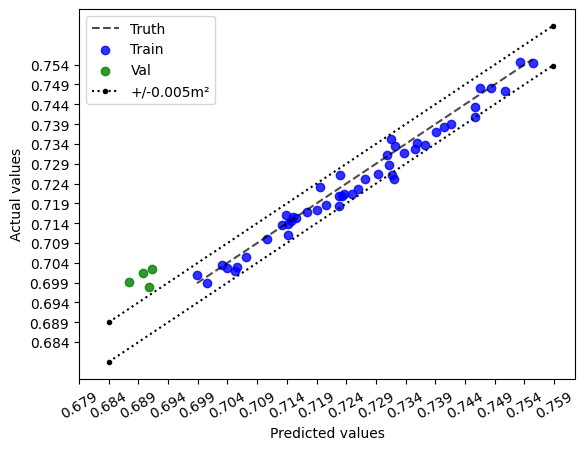

In [9]:
ax = plt.subplot()
display = PredictionErrorDisplay.from_predictions(CdA_train, CdA_pred_train, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "blue", 'label': 'Train'}, line_kwargs={'label': 'Truth'})

# display = PredictionErrorDisplay.from_predictions(CdA_test, CdA_pred_test, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "red", 'label': 'Test'}, line_kwargs={'visible': False})
display = PredictionErrorDisplay.from_predictions(CdA_validation, CdA_pred_validation, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "green", 'label': 'Val'}, line_kwargs={'visible': False})
limits = add_translated_lines(display, ERR)

# Add legend to the plot
display.ax_.set_aspect('auto')
display.ax_.legend()
display.ax_.xaxis.set_major_formatter('{x:1.3f}')
display.ax_.xaxis.set_tick_params(labelrotation=30)
display.ax_.yaxis.set_major_formatter('{x:1.3f}')
display.ax_.set_xticks(np.arange(limits[0] - ERR, limits[1] + ERR, ERR))
display.ax_.set_yticks(np.arange(limits[2] - ERR, limits[3] + ERR, ERR))
plt.show()


In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error


def compute_error_df(col_name):
    train = Y_training_phase[col_name]
    pred_train = Y_pred_train[:, Y.columns.get_loc(col_name)]
    # test = Y_test[col_name]
    # pred_test = Y_pred_test[:, Y.columns.get_loc(col_name)]
    validation = Y_validation_phase[col_name]
    pred_validation = Y_pred_validation[:, Y.columns.get_loc(col_name)]

    errors_train = {'R2_score': r2_score(train, pred_train), 
                    'MAE': mean_absolute_error(train, pred_train),
                    'MAPE': mean_absolute_percentage_error(train, pred_train),
                    'MaxE': max_error(train, pred_train)}
    # errors_test = {'R2_score': r2_score(test, pred_test), 
    #                 'MAE': mean_absolute_error(test, pred_test),
    #                 'MAPE': mean_absolute_percentage_error(test, pred_test),
    #                 'MaxE': max_error(test, pred_test)}
    errors_val = {'R2_score': r2_score(validation, pred_validation), 
                    'MAE': mean_absolute_error(validation, pred_validation),
                    'MAPE': mean_absolute_percentage_error(validation, pred_validation),
                    'MaxE': max_error(validation, pred_validation)}

    errors_df = pd.DataFrame([errors_train, errors_val], index=['Train', 'Val'])
    return errors_df

In [11]:
error_df = {col : compute_error_df(col) for col in ['CdA', 'CIA', 'CsA', 'CmrA', 'CmpA', 'CmyA']}
error_df = pd.concat(error_df.values(), axis=1, keys=error_df.keys()).transpose()
error_df

Train        Val
CdA  R2_score  0.965979 -32.374531
     MAE       0.002222   0.010434
     MAPE      0.003061   0.014884
     MaxE      0.006718   0.011789
CIA  R2_score  0.971250  -2.821953
     MAE       0.006071   0.010472
     MAPE      0.052182   0.210050
     MaxE      0.020326   0.015981
CsA  R2_score -0.030338  -4.544932
     MAE       0.007549   0.023897
     MAPE      0.501690   0.498498
     MaxE      0.023797   0.033273
CmrA R2_score  0.033524  -3.485959
     MAE       0.005546   0.013957
     MAPE      0.893541   0.405179
     MaxE      0.019739   0.018500
CmpA R2_score  0.992309  -0.426917
     MAE       0.005078   0.009530
     MAPE      0.063899   0.080123
     MaxE      0.013800   0.019058
CmyA R2_score -0.024682  -4.194117
     MAE       0.005506   0.012019
     MAPE      1.105992   0.839994
     MaxE      0.020450   0.017423

## Analysis

The R² scores are at a good level for CdA, ClA and CmpA, >95% for train and >80% for test. 
On the validation set, the score crumbles due to the very low amount of data and the shorter range of values (all points being around the same spot). 
The worse quality for CsA, CmrA and CMyA might be due to the data being generated on a CFD simulation converged for CdA, and numerical error may cause this loss of information.

Focusing on CdA, we can expect an error at ~10'''. Note that the validation points have been expected lower than their true value. We will probably find equivalent optimisation points since we seem to underestimate the values of minima.

The expert mixture finds the polynomial features as being of importance, even if the linear ElasticNet is also used

In [12]:
# This overly-complicated access to pipeline attributes returns the coefficients for the Expert Mixture prediction, ie the coefficient for each model in the final prediction.
# This gives us an idea of what models are used to make the final prediction
cda_col = Y.columns.get_loc('CdA')
pipeline['expert_mixture'].estimators_[cda_col].final_estimator_.coef_

array([0.28168245, 0.83826791])

# Optimisation


Now that we have a functioning pipeline, we can use it to optimise the performance.
Again, this is only for demonstration purpose, by minimising the CdA with no specific constraints added.

In a real world problem, we may want to be able to lock parameters to some values, reduce the range on which we can work with, have inequality constraints on other responses...

In [13]:
import warnings
warnings.filterwarnings('ignore')

def objective_function(x):
    y_pred = pipeline.predict(x.reshape(1, -1))
    cda_pred = y_pred[:, Y.columns.get_loc("CdA")]
    return cda_pred

bounds = [(demo_df[param].min(), demo_df[param].max()) for param in X_names]

We demonstrate optimisation using 3 different algorithms.
- Dual annealing : 2'19'', 0.684m², x = [ 0.000e+00  1.000e+01 -3.000e+01  5.000e+01  2.000e+01  2.000e+01  3.000e+01  4.000e+01  0.000e+00]
- SHGO           : 0'05'', 0.684m², x = [ 0.000e+00  1.000e+01 -3.000e+01  5.000e+01  2.000e+01  2.000e+01  3.000e+01  4.000e+01  0.000e+00]
- Evolution      : 0'05'', 0.684m², x = [ 0.000e+00  1.000e+01 -3.000e+01  5.000e+01  2.000e+01  2.000e+01  3.000e+01  4.000e+01  0.000e+00]

Annealing is the weakest algorithm here, as it takes a lot more time to find an optimum. All algorithm found the same result in the end, with an estimated CdA of 0.684m² (which is close to the 4 optimisation points estimated values)

In [14]:
# res_annealing = dual_annealing(objective_function, bounds)
# res_annealing

In [15]:
res_shgo = shgo(objective_function, bounds)
res_shgo

 message: Optimization terminated successfully.
 success: True
     fun: 0.6845724642733786
    funl: [ 6.846e-01  6.893e-01]
       x: [ 0.000e+00  1.000e+01 -3.000e+01  5.000e+01  2.000e+01
            2.000e+01  3.000e+01  4.000e+01  0.000e+00]
      xl: [[ 0.000e+00  1.000e+01 ...  4.000e+01  0.000e+00]
           [ 9.349e-19 -2.500e+01 ...  4.000e+01  1.000e+00]]
     nit: 1
    nfev: 614
   nlfev: 101
   nljev: 10
   nlhev: 0

In [16]:
res_diff = differential_evolution(objective_function, bounds)
res_diff

             message: Optimization terminated successfully.
             success: True
                 fun: 0.6845724642733786
                   x: [ 0.000e+00  1.000e+01 -3.000e+01  5.000e+01
                        2.000e+01  2.000e+01  3.000e+01  4.000e+01
                        0.000e+00]
                 nit: 2
                nfev: 775
          population: [[ 2.748e-01 -1.184e+01 ...  2.304e+01  6.678e-01]
                       [ 9.557e-01  6.484e+00 ...  2.965e+01  3.660e-01]
                       ...
                       [ 9.564e-01  7.185e+00 ...  3.071e+01  6.850e-01]
                       [ 3.378e-01 -1.640e+01 ...  2.337e+01  6.281e-01]]
 population_energies: [ 6.846e-01  7.057e-01 ...  7.108e-01  7.138e-01]
                 jac: [ 8.691e-03 -1.637e-04  8.443e-04 -2.058e-04
                       -8.370e-05 -1.253e-04 -3.010e-04 -7.768e-05
                        2.317e-03]

In [17]:
print(demo_df.iloc[-4:].loc[:,X_names])

    Front_Bumper_Curvature  Hood_Movement_X  Hood_Movement_Z  \
48                0.000036         7.752148        -29.99997   
49                0.000001         9.999977        -26.66046   
50                0.000001         9.999977        -26.66046   
51                0.000001         9.999977        -26.66046   

    Rear_Bumper_Wheel_Covering  Rear_Shoulder_1  Rear_Shoulder_2  \
48                    49.99992         6.211595         19.99979   
49                    49.99998        12.708150         20.00000   
50                    49.99998        -8.247176         20.00000   
51                    49.99998        -1.731245         20.00000   

    Side_Wall_Wheel_Covering_Y  Spoiler_Z  Veh_Apillar  
48                    29.99965   31.73340     0.382895  
49                    29.99975   31.73301     0.999995  
50                    29.99975   31.73301     0.999995  
51                    29.99975   31.73301     0.999995  


# Model persistence, reuse

In [18]:
from pickle import dumps, loads

In [19]:
# using stringification
stringed_model = dumps(pipeline, protocol=5)
loaded_pipe = loads(stringed_model)

pd.DataFrame(loaded_pipe.predict(X_validation_phase), columns=Y_names)

,CdA,CsA,CIA,CIA_Front,CIA_rear,CmrA,CmpA,CmyA,Vortex_CdA
0,0.687899,0.020436,0.064284,-0.022470,0.077254,0.016557,-0.129743,-0.001570,0.087193
1,0.690235,0.020023,0.064964,-0.014463,0.065452,0.016915,-0.102774,-0.001428,0.086881
2,0.691855,0.020023,0.061709,-0.015388,0.062747,0.016800,-0.099945,-0.001353,0.085611
3,0.691351,0.020023,0.062721,-0.015285,0.063588,0.016782,-0.100825,-0.001340,0.086006


# Optimisation loop

After the first DoE, let's imagine we launched the experiments that we used as validation (which were not seen when building the model).
We got 4 additional points, let's update the surrogate with these new points to see if we have differences

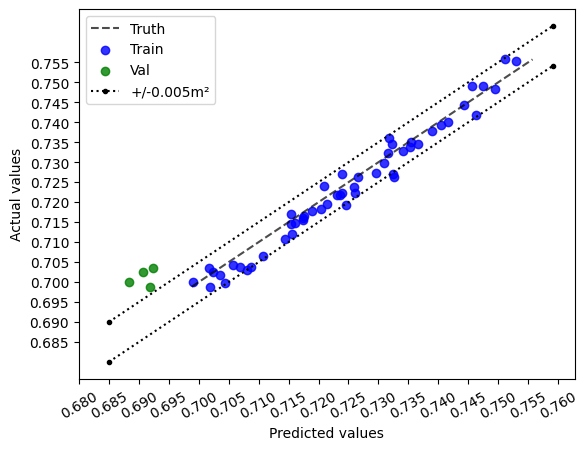

In [20]:
pipeline.fit(X, Y)
Y_pred = pipeline.predict(X)

# We focus on the CdA prediction
CdA_loop = Y["CdA"]
CdA_pred_loop = Y_pred[:, Y.columns.get_loc("CdA")]

ax = plt.subplot()
display = PredictionErrorDisplay.from_predictions(CdA_loop, CdA_pred_loop, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "blue", 'label': 'Train'}, line_kwargs={'label': 'Truth'})

# display = PredictionErrorDisplay.from_predictions(CdA_test, CdA_pred_test, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "red", 'label': 'Test'}, line_kwargs={'visible': False})
display = PredictionErrorDisplay.from_predictions(CdA_validation, CdA_pred_validation, kind="actual_vs_predicted", ax=ax, scatter_kwargs={"color": "green", 'label': 'Val'}, line_kwargs={'visible': False})
limits = add_translated_lines(display, ERR)

# Add legend to the plot
display.ax_.set_aspect('auto')
display.ax_.legend()
display.ax_.xaxis.set_major_formatter('{x:1.3f}')
display.ax_.xaxis.set_tick_params(labelrotation=30)
display.ax_.yaxis.set_major_formatter('{x:1.3f}')
display.ax_.set_xticks(np.arange(limits[0] - ERR, limits[1] + ERR, ERR))
display.ax_.set_yticks(np.arange(limits[2] - ERR, limits[3] + ERR, ERR))
plt.show()

In [21]:
res_shgo = shgo(objective_function, bounds)
res_shgo.x

array([  0.,  10., -30.,  50.,  20., -20.,  30.,  40.,   0.])